In [1]:
import os
import sys

# Set working directory to project root so relative paths in config resolve correctly
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.dataset_loader import load_all

In [2]:
# ----- Loading data ----- #
df = load_all() # -> load all crypto
df.shape


(20935, 27)

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 20935 entries, 2020-01-22 to 2026-02-16
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   symbol         20935 non-null  str    
 1   open           20935 non-null  float64
 2   high           20935 non-null  float64
 3   low            20935 non-null  float64
 4   close          20935 non-null  float64
 5   volume         20935 non-null  float64
 6   body           20935 non-null  float64
 7   upper_wick     20935 non-null  float64
 8   lower_wick     20935 non-null  float64
 9   range          20935 non-null  float64
 10  return_1d      20935 non-null  float64
 11  return_3d      20935 non-null  float64
 12  return_7d      20935 non-null  float64
 13  return_14d     20935 non-null  float64
 14  return_21d     20935 non-null  float64
 15  ema9_ratio     20935 non-null  float64
 16  ema21_ratio    20935 non-null  float64
 17  ema50_ratio    20935 non-null  float64
 18  

In [4]:
df.describe()

,open,high,low,close,volume,body,upper_wick,lower_wick,range,return_1d,...,ema50_ratio,ema100_ratio,rsi,macd,macd_signal,macd_hist,volume_ratio,volume_return,volatility,label
count,20935.000000,20935.000000,20935.000000,20935.000000,2.093500e+04,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,...,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000,20935.000000
mean,5404.345957,5517.573996,5281.956716,5407.346261,2.914990e+08,0.002550,0.018564,0.020710,0.074192,0.002562,...,1.011338,1.020740,0.506680,-0.003308,-0.003063,-0.000245,1.023854,0.135324,0.046311,0.008741
std,17987.802168,18322.815288,17623.865850,17993.122781,1.674871e+09,0.061072,0.023829,0.024174,0.069244,0.061069,...,0.190086,0.273356,0.171425,0.062120,0.058802,0.017662,0.636154,0.918530,0.039406,0.850016
min,0.001497,0.001643,0.001135,0.001582,3.104117e+03,-0.518440,0.000000,0.000000,0.003391,-0.518694,...,0.208538,0.154584,0.044382,-0.404589,-0.344972,-0.207043,0.106527,-0.953546,0.005383,-1.000000
25%,0.561900,0.583050,0.540500,0.562050,7.489573e+05,-0.022397,0.005934,0.007173,0.038379,-0.022404,...,0.908097,0.866192,0.377099,-0.033370,-0.032349,-0.008893,0.640911,-0.263409,0.027620,-1.000000
50%,13.180000,13.690000,12.700000,13.191600,4.964215e+06,0.000238,0.012333,0.014077,0.057941,0.000274,...,1.006628,1.000091,0.496971,-0.002319,-0.002168,0.000246,0.886558,-0.021674,0.038857,0.000000
75%,372.925000,385.425000,359.550000,373.665000,1.770678e+08,0.023105,0.023416,0.025452,0.088928,0.023148,...,1.101760,1.155584,0.630072,0.030383,0.029443,0.009302,1.221621,0.329575,0.054142,1.000000
max,124658.540000,126199.630000,123084.000000,124658.540000,1.090737e+11,3.925443,1.141378,0.567747,4.074935,3.924114,...,2.285944,3.225829,0.996794,0.266066,0.216768,0.092051,15.987630,90.839944,1.064640,1.000000


In [5]:
df.head()

,symbol,open,high,low,close,volume,body,upper_wick,lower_wick,range,...,ema50_ratio,ema100_ratio,rsi,macd,macd_signal,macd_hist,volume_ratio,volume_return,volatility,label
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-22,BTC_USDT,8736.04,8818.00,8590.00,8682.36,29080.557138,-0.006145,0.009382,0.010572,0.026099,...,0.902949,0.871417,0.627133,0.042403,0.040803,0.001600,0.481676,-0.203156,0.031103,-1
2020-01-23,BTC_USDT,8682.77,8691.81,8306.39,8404.52,48165.944597,-0.032046,0.001041,0.011302,0.044389,...,0.935435,0.902200,0.617207,0.039189,0.040480,-0.001291,0.811414,0.656294,0.031322,1
2020-01-24,BTC_USDT,8404.52,8528.02,8238.00,8439.00,41687.529529,0.004103,0.010592,0.019813,0.034508,...,0.934295,0.900523,0.556057,0.035309,0.039446,-0.004137,0.695424,-0.134502,0.028791,1
2020-01-25,BTC_USDT,8438.99,8451.26,8254.90,8340.58,25521.157932,-0.011661,0.001454,0.010153,0.023268,...,0.947464,0.912909,0.577070,0.031428,0.037843,-0.006414,0.430337,-0.387799,0.028271,1
2020-01-26,BTC_USDT,8340.01,8618.13,8293.66,8615.00,31130.485164,0.032972,0.000375,0.005558,0.038905,...,0.920527,0.886130,0.598215,0.029362,0.036146,-0.006784,0.535535,0.219791,0.029036,1


In [6]:
df.dtypes

symbol               str
open             float64
high             float64
low              float64
close            float64
volume           float64
body             float64
upper_wick       float64
lower_wick       float64
range            float64
return_1d        float64
return_3d        float64
return_7d        float64
return_14d       float64
return_21d       float64
ema9_ratio       float64
ema21_ratio      float64
ema50_ratio      float64
ema100_ratio     float64
rsi              float64
macd             float64
macd_signal      float64
macd_hist        float64
volume_ratio     float64
volume_return    float64
volatility       float64
label              int64
dtype: object

In [7]:
df.isnull().sum()


symbol           0
open             0
high             0
low              0
close            0
volume           0
body             0
upper_wick       0
lower_wick       0
range            0
return_1d        0
return_3d        0
return_7d        0
return_14d       0
return_21d       0
ema9_ratio       0
ema21_ratio      0
ema50_ratio      0
ema100_ratio     0
rsi              0
macd             0
macd_signal      0
macd_hist        0
volume_ratio     0
volume_return    0
volatility       0
label            0
dtype: int64

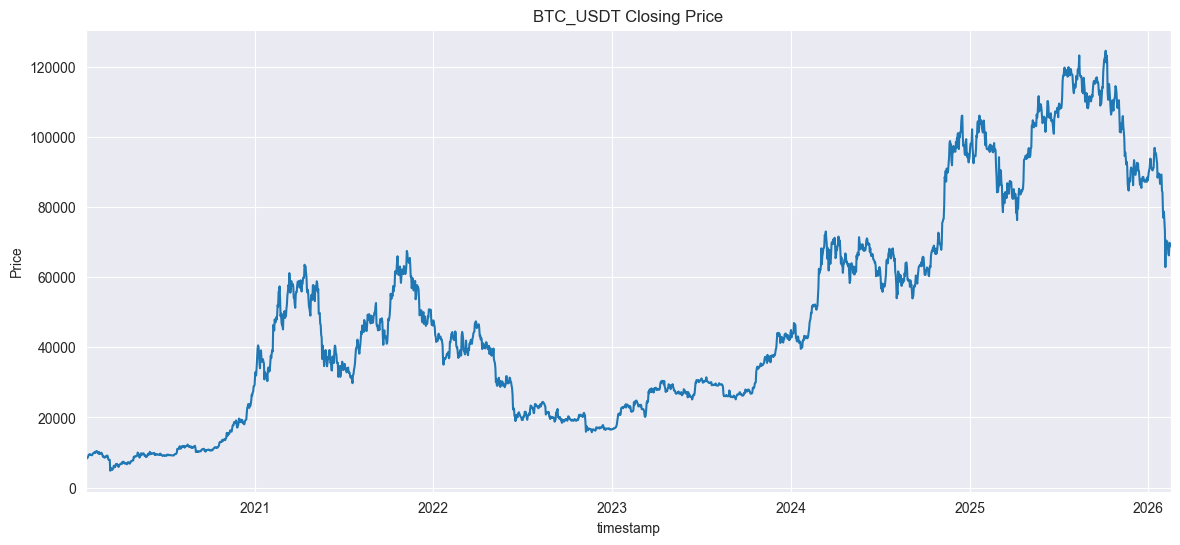

In [12]:
value = df[df["symbol"] == "BTC_USDT"]
value["close"].plot(title=f"{value['symbol'].iloc[0]} Closing Price", ylabel="Price", figsize=(14, 6))
plt.show()


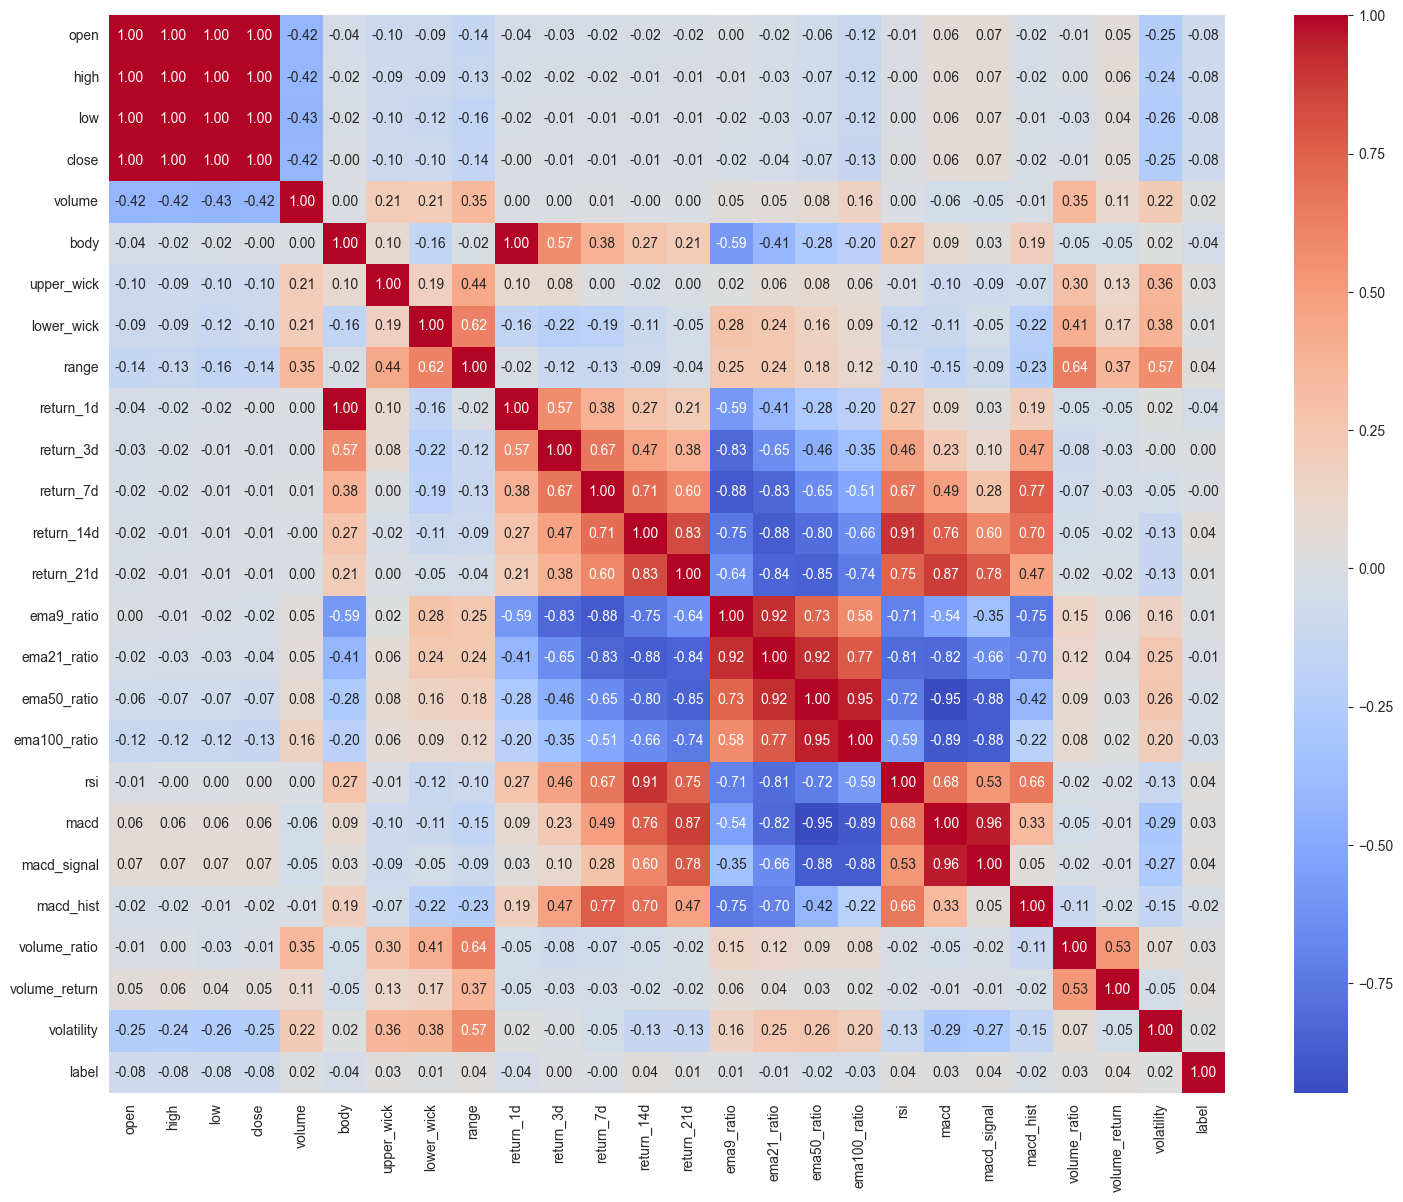

In [17]:
corr = value.drop(columns="symbol").corr()
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [18]:
def top_correlations(corr_matrix: pd.DataFrame, target: str = "label", n: int = 10) -> pd.DataFrame:
    """Retourne les n features les plus corrélées avec la colonne cible.

    Args:
        corr_matrix: Matrice de corrélation (DataFrame).
        target: Colonne cible (par défaut 'label').
        n: Nombre de features à afficher.

    Returns:
        DataFrame trié par corrélation absolue décroissante.
    """
    corr_with_target = corr_matrix[target].drop(target)
    ranked = corr_with_target.abs().sort_values(ascending=False).head(n)
    result = pd.DataFrame({
        "correlation": corr_with_target[ranked.index],
        "abs_correlation": ranked
    })
    return result

top_correlations(corr, target="label", n=15)

,correlation,abs_correlation
close,-0.079915,0.079915
low,-0.079303,0.079303
high,-0.078495,0.078495
open,-0.078128,0.078128
return_14d,0.044704,0.044704
range,0.042993,0.042993
volume_return,0.041686,0.041686
rsi,0.039914,0.039914
return_1d,-0.037537,0.037537
body,-0.037528,0.037528


In [ ]:
BEST_FEATURES_SET = [
    "close",
    "volume",
    "return_1d",
    "return_3d",
    "return_7d",
    "rsi",
    "ema9_ratio",
    "ema100_ratio",
    "macd_hist",
    "volume_ratio",
    "volume_return",
    "volatility",
    "upper_wick",
    "lower_wick",
    "range",
]